In [1]:
# ================== Notebook Setup ==================
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# ================== Data Library ==================
from __future__ import annotations

import json
import seaborn as sns
import random
import sys
from datetime import datetime
from pathlib import Path

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    make_scorer,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# ================== Global Configuration ==================
RANDOM_STATE = 42

# Section 1: Data Collection and Ingestion

In [3]:
DATA_PATH = "ecommerce_customer_churn_dataset.csv"
TARGET = "Churned"

raw_data = pd.read_csv(DATA_PATH)
raw_data.columns = raw_data.columns.str.strip()

print(f"Dataset shape: {raw_data.shape}")

Dataset shape: (50000, 25)


In [4]:
raw_data.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [6]:
duplicate_rows = raw_data.duplicated().sum()
duplicate_rows

np.int64(0)

In [7]:
missing_summary = (
    raw_data.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
      .assign(missing_ratio=lambda x: (x["missing_count"] / len(raw_data)).round(2))
      .sort_values("missing_ratio", ascending=False)
)

missing_summary

,missing_count,missing_ratio
Social_Media_Engagement_Score,6000,0.12
Credit_Balance,5500,0.11
Mobile_App_Usage,5000,0.10
Returns_Rate,4491,0.09
Wishlist_Items,4000,0.08
Discount_Usage_Rate,3500,0.07
Session_Duration_Avg,3399,0.07
Product_Reviews_Written,3500,0.07
Days_Since_Last_Purchase,3000,0.06
Pages_Per_Session,3000,0.06


## Create a Test Set

In [8]:
df = raw_data.copy()

# Split before fitting imputation values (avoid leakage)
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y, 
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

print("\nClass ratio - full:")
print(y.value_counts(normalize=True))
print("\nClass ratio - train:")
print(y_train.value_counts(normalize=True))
print("\nClass ratio - test:")
print(y_test.value_counts(normalize=True))

X_train: (40000, 24) y_train: (40000,)
X_test: (10000, 24) y_test: (10000,)

Class ratio - full:
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

Class ratio - train:
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

Class ratio - test:
Churned
0    0.711
1    0.289
Name: proportion, dtype: float64


In [9]:
# Identify column types from train split
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# Use >= 5% threshold for adding missing indicators
train_missing_ratio = X_train.isna().mean()
indicator_cols = train_missing_ratio[train_missing_ratio >= 0.05].index.tolist()

# Apply imputation to train/test
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Add missing indicators BEFORE imputation
for col in indicator_cols:
    X_train_processed[f"{col}_missing"] = X_train_processed[col].isna().astype("int8")
    X_test_processed[f"{col}_missing"] = X_test_processed[col].isna().astype("int8")

# A. Behaviour variables:
zero_fill_cols = [
    "Wishlist_Items",
    "Product_Reviews_Written",
    "Mobile_App_Usage",
    "Social_Media_Engagement_Score",
    "Email_Open_Rate"
]

# B. Ambiguous rate variables:
ambiguous_rate_cols = [
    "Discount_Usage_Rate",
    "Returns_Rate"
]

# C. Historical record variable:
special_sentinel_col = "Days_Since_Last_Purchase"

# D. Remaining numeric variables -> median imputation
median_fill_numeric_cols = [
    col for col in numerical_cols
    if col not in zero_fill_cols + ambiguous_rate_cols + [special_sentinel_col]
]

for col in categorical_cols:
    X_train_processed[col] = X_train_processed[col].fillna("Missing")
    X_test_processed[col] = X_test_processed[col].fillna("Missing")

# Zero-fill behaviour-like variables
for col in zero_fill_cols:
    if col in X_train_processed.columns:
        X_train_processed[col] = X_train_processed[col].fillna(0)
        X_test_processed[col] = X_test_processed[col].fillna(0)

# Special handling for Days_Since_Last_Purchase
if special_sentinel_col in X_train_processed.columns:
    sentinel_value = X_train_processed[special_sentinel_col].max(skipna=True) + 1

    if pd.isna(sentinel_value):
        sentinel_value = 999

    X_train_processed[special_sentinel_col] = X_train_processed[special_sentinel_col].fillna(sentinel_value)
    X_test_processed[special_sentinel_col] = X_test_processed[special_sentinel_col].fillna(sentinel_value)

# Median-fill ambiguous rate variables
if ambiguous_rate_cols:
    ambiguous_fill_values = X_train_processed[ambiguous_rate_cols].median(numeric_only=True)

    for col in ambiguous_rate_cols:
        if col in X_train_processed.columns:
            X_train_processed[col] = X_train_processed[col].fillna(ambiguous_fill_values[col])
            X_test_processed[col] = X_test_processed[col].fillna(ambiguous_fill_values[col])

# Median-fill remaining numeric variables
if median_fill_numeric_cols:
    median_fill_values = X_train_processed[median_fill_numeric_cols].median(numeric_only=True)

    for col in median_fill_numeric_cols:
        X_train_processed[col] = X_train_processed[col].fillna(median_fill_values[col])
        X_test_processed[col] = X_test_processed[col].fillna(median_fill_values[col])

# Cast categorical columns to category dtype
for col in categorical_cols:
    X_train_processed[col] = X_train_processed[col].astype("category")
    X_test_processed[col] = X_test_processed[col].astype("category")


train_missing_after = X_train_processed.isna().sum().sum()
test_missing_after = X_test_processed.isna().sum().sum()

print("=== Missing value processing complete ===")
print(f"X_train shape: {X_train_processed.shape}")
print(f"X_test shape:  {X_test_processed.shape}")
print(f"Remaining missing values in X_train: {train_missing_after}")
print(f"Remaining missing values in X_test:  {test_missing_after}")

print("\nAdded missing indicators:")
added_flags = [col for col in X_train_processed.columns if col.endswith("_missing")]
print(added_flags if added_flags else "None")

print("\nZero-filled columns:")
print(zero_fill_cols)

print("\nMedian-filled numeric columns:")
print(median_fill_numeric_cols)

print("\nAmbiguous rate columns (median-filled):")
print(ambiguous_rate_cols)

print(f"\nSpecial sentinel used for {special_sentinel_col}: {sentinel_value if special_sentinel_col in X_train_processed.columns else 'N/A'}")

=== Missing value processing complete ===
X_train shape: (40000, 36)
X_test shape:  (10000, 36)
Remaining missing values in X_train: 0
Remaining missing values in X_test:  0

Added missing indicators:
['Session_Duration_Avg_missing', 'Pages_Per_Session_missing', 'Wishlist_Items_missing', 'Days_Since_Last_Purchase_missing', 'Discount_Usage_Rate_missing', 'Returns_Rate_missing', 'Email_Open_Rate_missing', 'Product_Reviews_Written_missing', 'Social_Media_Engagement_Score_missing', 'Mobile_App_Usage_missing', 'Payment_Method_Diversity_missing', 'Credit_Balance_missing']

Zero-filled columns:
['Wishlist_Items', 'Product_Reviews_Written', 'Mobile_App_Usage', 'Social_Media_Engagement_Score', 'Email_Open_Rate']

Median-filled numeric columns:
['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Total_Purchases', 'Average_Order_Value', 'Customer_Service_Calls', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance']

Ambig

# Section 2: Exploratory Data Analysis and Insight Generation

In this section, we focus on **understanding churn behavior** before modeling:
1. Check target balance and baseline churn rate.
2. Quantify which numeric features separate churned vs non-churned users.
3. Evaluate categorical patterns (country/city/quarter/gender).
4. Test whether missingness itself carries signal.
5. Detect skew, outliers, and suspicious values that may affect model design.
6. Explore a high-value interaction pattern.

In [13]:
eda_df = pd.concat([X_train.copy(), y_train.copy()], axis=1)
eda_df["Churned"] = eda_df["Churned"].astype(int)

eda_df.shape
eda_df.head()

(40000, 25)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Signup_Quarter,Churned
48395,24.0,Male,USA,Houston,1.2,9.0,38.9,7.5,53.9,9.0,...,46.1,9.0,2.0,22.2,25.5,2.0,617.37,2187.0,Q2,0
43060,49.0,Male,USA,New York,3.3,28.0,58.4,21.3,12.2,13.0,...,42.4,3.0,6.0,72.6,48.2,1.0,3500.79,3173.0,Q2,0
22404,56.0,Female,Germany,Hamburg,1.7,9.0,NaN,11.5,67.6,3.0,...,12.4,7.0,4.0,26.2,19.2,2.0,2426.02,2582.0,Q3,1
8602,69.0,Male,USA,Los Angeles,1.8,11.0,44.2,13.4,36.0,NaN,...,16.2,8.0,8.0,13.7,26.9,4.0,1433.75,3789.0,Q4,0
31036,47.0,Female,India,Hyderabad,4.9,12.0,33.4,12.5,60.6,9.0,...,39.1,2.0,4.0,42.3,21.2,2.0,2318.70,1540.0,Q3,0


## 2.1 Target Distribution

Class counts:


,count
Churned,
Non-Churned,28440
Churned,11560


Overall churn rate: 28.90%


/var/folders/2j/pl598g1j2xz2pdz1zs5r31vr0000gn/T/ipykernel_88367/829804902.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x="Churned", palette=["#4C78A8", "#F58518"], ax=ax)


<Axes: xlabel='Churned', ylabel='count'>

...

Text(0.5, 1.0, 'Target Distribution')

Text(0.5, 0, '')

Text(0, 0.5, 'Customers')

Text(0.0, 28440.0, '28,440')

Text(1.0, 11560.0, '11,560')

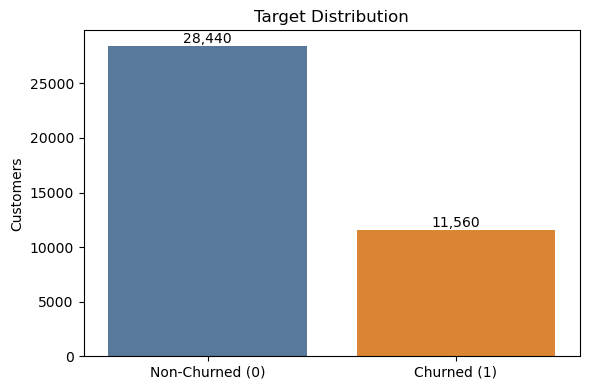

In [14]:
target_counts = eda_df["Churned"].value_counts().sort_index()
target_rate = eda_df["Churned"].mean()

print("Class counts:")
display(target_counts.rename(index={0: "Non-Churned", 1: "Churned"}).to_frame("count"))

print(f"Overall churn rate: {target_rate:.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda_df, x="Churned", palette=["#4C78A8", "#F58518"], ax=ax)
ax.set_xticklabels(["Non-Churned (0)", "Churned (1)"])
ax.set_title("Target Distribution")
ax.set_xlabel("")
ax.set_ylabel("Customers")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


**Interpretation:**  
The dataset is moderately imbalanced (about **71% non-churned vs 29% churned**). This is not extreme, but it is enough to require stratified splits and metric choices beyond raw accuracy in the modeling stage.

## 2.2 Numeric feature signal ranking (churn vs non-churn)

In [15]:
numeric_cols = [c for c in eda_df.select_dtypes(include=np.number).columns if c != "Churned"]

def cohen_d(x0, x1):
    x0 = x0.dropna()
    x1 = x1.dropna()
    if len(x0) < 2 or len(x1) < 2:
        return np.nan
    s0, s1 = x0.std(ddof=1), x1.std(ddof=1)
    pooled = np.sqrt(((len(x0)-1)*(s0**2) + (len(x1)-1)*(s1**2)) / (len(x0)+len(x1)-2))
    return (x1.mean() - x0.mean()) / pooled if pooled > 0 else np.nan

rows = []
for col in numeric_cols:
    g0 = eda_df.loc[eda_df["Churned"] == 0, col]
    g1 = eda_df.loc[eda_df["Churned"] == 1, col]
    rows.append({
        "feature": col,
        "mean_non_churn": g0.mean(),
        "mean_churn": g1.mean(),
        "median_non_churn": g0.median(),
        "median_churn": g1.median(),
        "mean_diff_churn_minus_nonchurn": g1.mean() - g0.mean(),
        "cohen_d": cohen_d(g0, g1),
        "missing_pct": eda_df[col].isna().mean() * 100
    })

numeric_signal_df = (
    pd.DataFrame(rows)
    .assign(abs_cohen_d=lambda x: x["cohen_d"].abs())
    .sort_values("abs_cohen_d", ascending=False)
)

display(numeric_signal_df.head(12))


,feature,mean_non_churn,mean_churn,median_non_churn,median_churn,mean_diff_churn_minus_nonchurn,cohen_d,missing_pct,abs_cohen_d
13,Customer_Service_Calls,5.189228,6.891032,5.0,7.0,1.701804,0.664071,0.3500,0.664071
5,Cart_Abandonment_Rate,54.169490,64.124785,55.5,66.6,9.955295,0.636195,0.0000,0.636195
4,Pages_Per_Session,9.298703,7.381821,9.0,6.9,-1.916882,-0.520917,5.8975,0.520917
3,Session_Duration_Avg,29.235056,23.755296,28.2,22.1,-5.479760,-0.516568,6.7225,0.516568
12,Email_Open_Rate,22.913629,15.933467,21.8,13.5,-6.980162,-0.501835,5.0450,0.501835
16,Mobile_App_Usage,20.720537,16.117291,20.0,14.8,-4.603246,-0.500953,10.0325,0.500953
2,Login_Frequency,12.652496,9.147059,12.0,8.0,-3.505438,-0.458209,0.0000,0.458209
6,Wishlist_Items,4.699755,3.312653,4.0,3.0,-1.387103,-0.443611,8.0250,0.443611
15,Social_Media_Engagement_Score,31.901131,23.319876,30.4,20.1,-8.581256,-0.423343,11.9125,0.423343
14,Product_Reviews_Written,3.124835,2.201754,3.0,2.0,-0.923081,-0.401502,6.9300,0.401502


**Interpretation:**  
The strongest numeric churn signals are behavioral engagement and friction features. In this dataset, the largest separations are typically:
- **higher** `Customer_Service_Calls` and `Cart_Abandonment_Rate` among churned customers
- **lower** engagement among churned customers (`Session_Duration_Avg`, `Pages_Per_Session`, `Login_Frequency`, `Email_Open_Rate`, `Mobile_App_Usage`)

These are high-priority candidates for modeling.

## 2.3 Visual check of top numeric drivers

We now visualize top-ranked numeric features to confirm the direction and spread differences seen in the ranking table.


/var/folders/2j/pl598g1j2xz2pdz1zs5r31vr0000gn/T/ipykernel_88367/3678329419.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='Churned', ylabel='Customer_Service_Calls'>

/var/folders/2j/pl598g1j2xz2pdz1zs5r31vr0000gn/T/ipykernel_88367/3678329419.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0", "1"])


[Text(0, 0, '0'), Text(1, 0, '1')]

Text(0.5, 1.0, 'Customer_Service_Calls')

...

<Axes: xlabel='Churned', ylabel='Mobile_App_Usage'>

/var/folders/2j/pl598g1j2xz2pdz1zs5r31vr0000gn/T/ipykernel_88367/3678329419.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0", "1"])


[Text(0, 0, '0'), Text(1, 0, '1')]

Text(0.5, 1.0, 'Mobile_App_Usage')

Text(0.5, 1.02, 'Top Numeric Features by Churn Class (1st-99th pct clipped for display)')

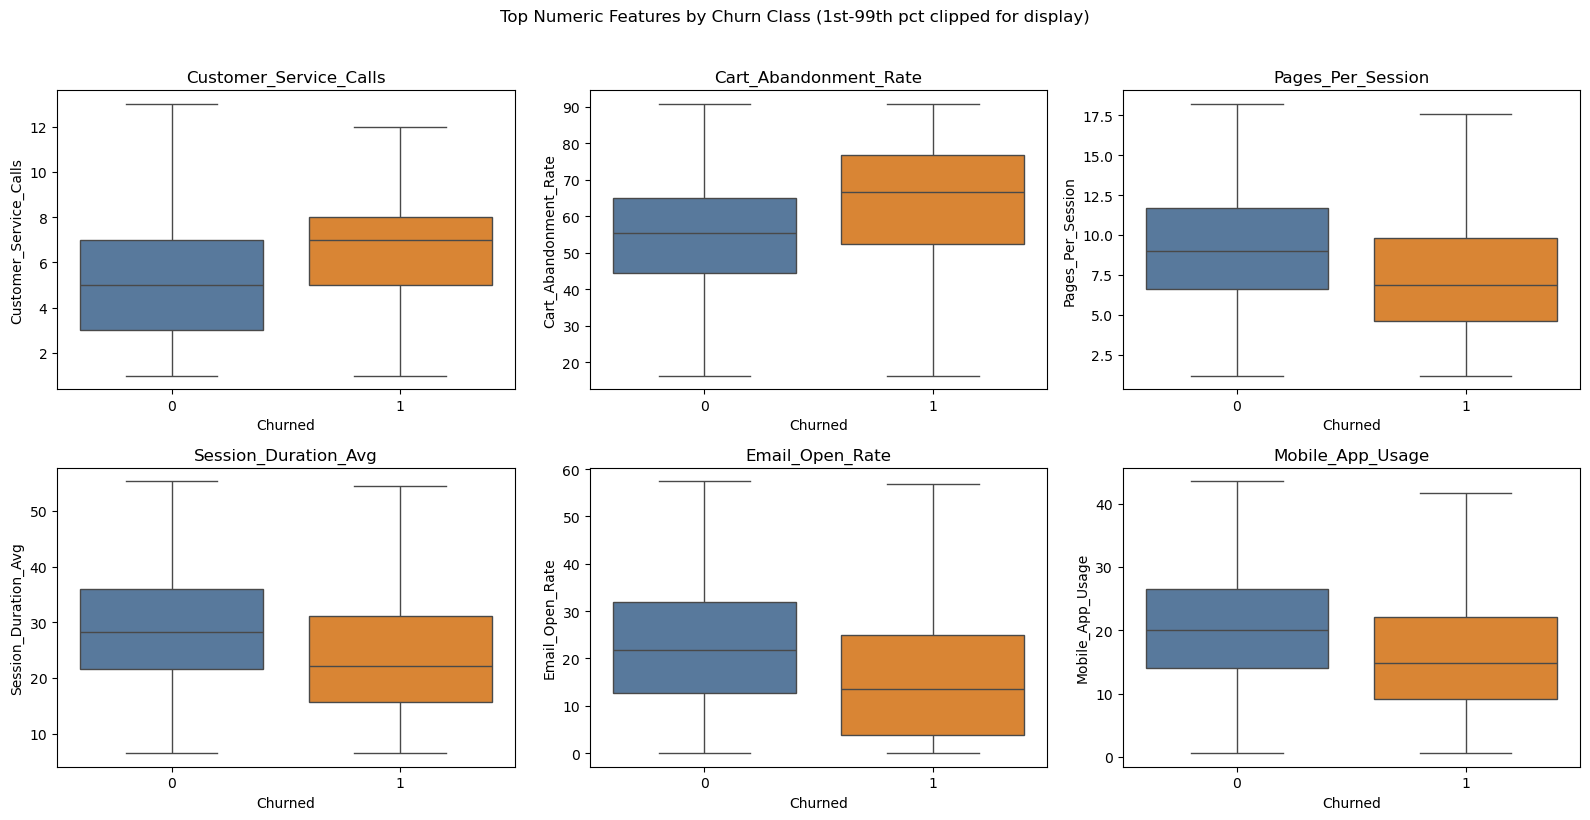

In [16]:
top_numeric = numeric_signal_df["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_numeric):
    plot_df = eda_df[[col, "Churned"]].dropna().copy()
    # Clip only for plotting stability (not for modeling)
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(lo, hi)

    sns.boxplot(
        data=plot_df, x="Churned", y=col,
        palette=["#4C78A8", "#F58518"], ax=ax, showfliers=False
    )
    ax.set_xticklabels(["0", "1"])
    ax.set_title(col)

for i in range(len(top_numeric), len(axes)):
    axes[i].axis("off")

plt.suptitle("Top Numeric Features by Churn Class (1st-99th pct clipped for display)", y=1.02)
plt.tight_layout()
plt.show()


**Interpretation:**  
The plots should confirm clear class separation for top features, especially service-call intensity and abandonment behavior. Even with overlap (expected in real customer data), the central tendency shift is strong enough to be useful.


## 2.4 Categorical Feature Analysis

For categorical variables, we compare churn rates by category level and against the global baseline.  
This helps detect segment-level risk pockets.


Signup_Quarter (levels with >=200 rows):


,Signup_Quarter,count,churn_rate
0,Q1,9953,0.293680
1,Q2,9989,0.293122
2,Q3,10060,0.286481
3,Q4,9998,0.282757


<Figure size 900x500 with 0 Axes>

<Axes: xlabel='churn_rate', ylabel='Signup_Quarter'>

Text(0.5, 1.0, 'Signup_Quarter: Churn Rate by Category (Top 12 by volume)')

Text(0.5, 0, 'Churn rate')

Text(0, 0.5, '')

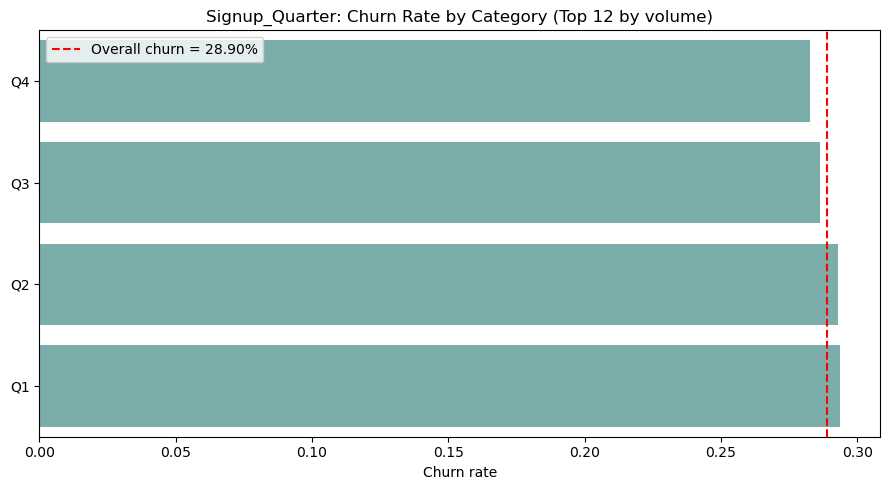


Gender (levels with >=200 rows):


,Gender,count,churn_rate
2,Other,762,0.304462
0,Female,20083,0.290395
1,Male,19155,0.286922


<Figure size 900x500 with 0 Axes>

<Axes: xlabel='churn_rate', ylabel='Gender'>

Text(0.5, 1.0, 'Gender: Churn Rate by Category (Top 12 by volume)')

Text(0.5, 0, 'Churn rate')

Text(0, 0.5, '')

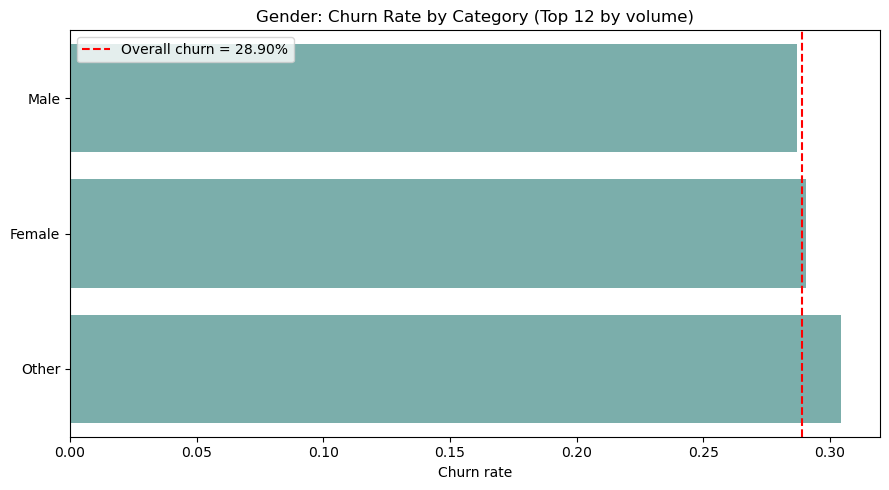


Country (levels with >=200 rows):


,Country,count,churn_rate
0,Australia,3197,0.299343
4,India,2790,0.292473
7,USA,13999,0.291164
6,UK,5998,0.291097
1,Canada,4772,0.290863
3,Germany,3961,0.288816
5,Japan,2066,0.279284
2,France,3217,0.266086


<Figure size 900x500 with 0 Axes>

<Axes: xlabel='churn_rate', ylabel='Country'>

Text(0.5, 1.0, 'Country: Churn Rate by Category (Top 12 by volume)')

Text(0.5, 0, 'Churn rate')

Text(0, 0.5, '')

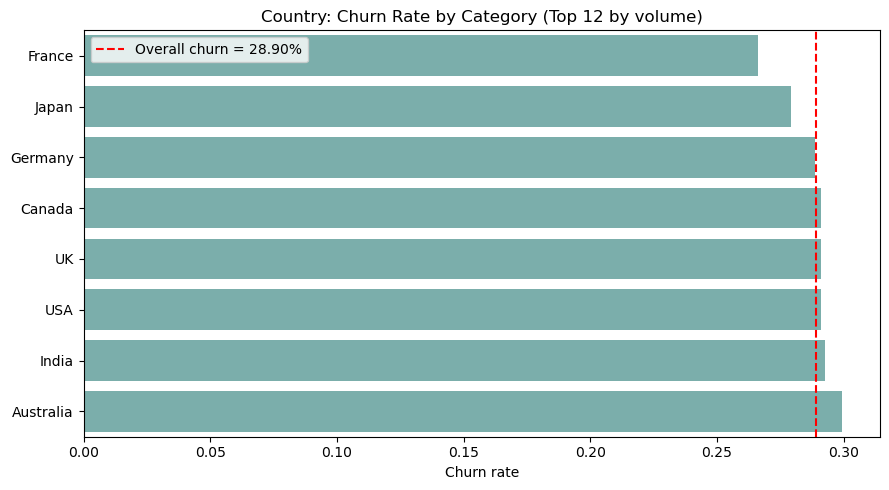


City (levels with >=200 rows):


,City,count,churn_rate
34,Sydney,662,0.317221
15,Kyoto,413,0.314770
22,Melbourne,649,0.314330
24,Mumbai,550,0.309091
21,Marseille,644,0.309006
9,Delhi,555,0.304505
16,Leeds,1209,0.303557
32,Perth,626,0.303514
4,Brisbane,621,0.302738
12,Hamburg,812,0.301724


<Figure size 900x500 with 0 Axes>

<Axes: xlabel='churn_rate', ylabel='City'>

Text(0.5, 1.0, 'City: Churn Rate by Category (Top 12 by volume)')

Text(0.5, 0, 'Churn rate')

Text(0, 0.5, '')

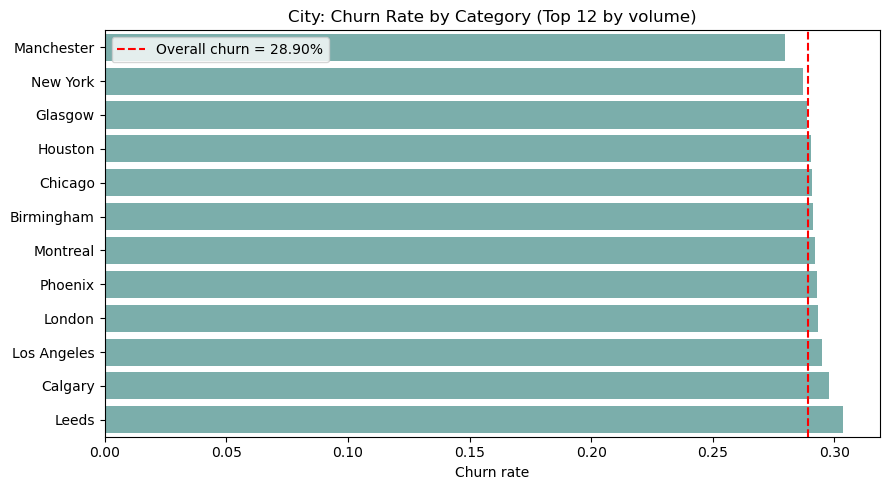

In [17]:
cat_cols = eda_df.select_dtypes(exclude=np.number).columns.tolist()
baseline = eda_df["Churned"].mean()

def category_churn_table(df, col, min_count=200):
    tmp = (
        df.groupby(col, dropna=False)["Churned"]
          .agg(count="size", churn_rate="mean")
          .reset_index()
          .sort_values("churn_rate", ascending=False)
    )
    return tmp[tmp["count"] >= min_count].copy()

selected_cats = [c for c in ["Signup_Quarter", "Gender", "Country", "City"] if c in cat_cols]

for col in selected_cats:
    tmp = category_churn_table(eda_df, col, min_count=200)
    print(f"\n{col} (levels with >=200 rows):")
    display(tmp.head(12))

    top_plot = tmp.sort_values("count", ascending=False).head(12).sort_values("churn_rate", ascending=True)
    plt.figure(figsize=(9, 5))
    sns.barplot(data=top_plot, x="churn_rate", y=col, color="#72B7B2")
    plt.axvline(baseline, color="red", linestyle="--", label=f"Overall churn = {baseline:.2%}")
    plt.title(f"{col}: Churn Rate by Category (Top 12 by volume)")
    plt.xlabel("Churn rate")
    plt.ylabel("")
    plt.legend()
    plt.tight_layout()
    plt.show()


**Interpretation:**  
Categorical features show signal, but generally weaker than top numeric behavior features.  
`City` tends to show more spread than broader categories like `Country` or `Signup_Quarter`, which suggests local market or operational heterogeneity that could still add incremental predictive value.

## 2.5 Missingness as Signal

Missing values can be informative (not just noise).  
We compare missing rates between churned and non-churned groups to identify where a “missing indicator” may be predictive.

,feature,missing_non_churn,missing_churn,gap_churn_minus_nonchurn,abs_gap
6,Session_Duration_Avg,0.055872,0.095156,0.039284,0.039284
15,Email_Open_Rate,0.042089,0.071021,0.028932,0.028932
13,Discount_Usage_Rate,0.073383,0.064100,-0.009282,0.009282
0,Age,0.051969,0.043253,-0.008716,0.008716
18,Social_Media_Engagement_Score,0.117370,0.123443,0.006073,0.006073
14,Returns_Rate,0.088643,0.094204,0.005561,0.005561
17,Product_Reviews_Written,0.067968,0.072578,0.004610,0.004610
12,Days_Since_Last_Purchase,0.059142,0.063149,0.004007,0.004007
22,Credit_Balance,0.107841,0.111246,0.003405,0.003405
20,Payment_Method_Diversity,0.051055,0.048183,-0.002871,0.002871


<Figure size 1000x500 with 0 Axes>

/var/folders/2j/pl598g1j2xz2pdz1zs5r31vr0000gn/T/ipykernel_88367/1915338717.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_missing, x="gap_churn_minus_nonchurn", y="feature", palette="coolwarm")


<Axes: xlabel='gap_churn_minus_nonchurn', ylabel='feature'>

Text(0.5, 1.0, 'Missingness Rate Gap by Churn Class')

Text(0.5, 0, 'Missing rate gap (Churned - Non-Churned)')

Text(0, 0.5, '')

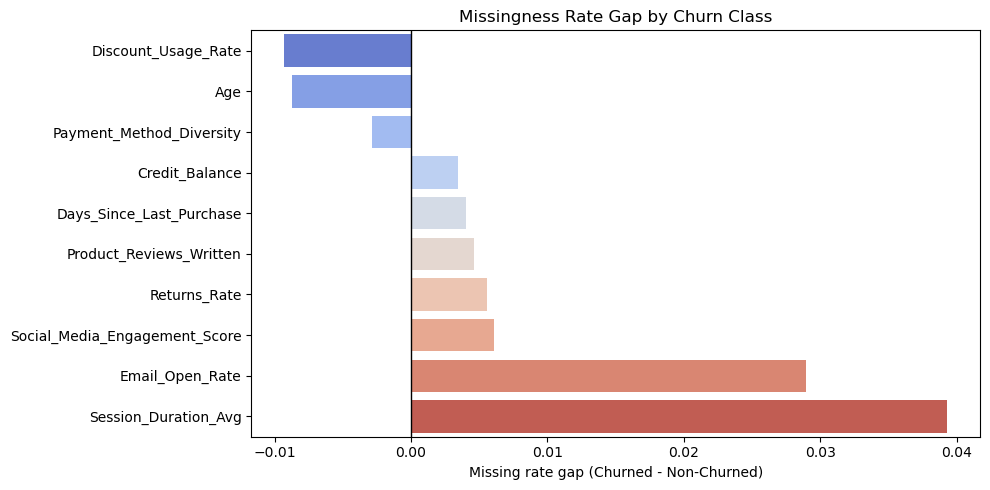

In [18]:
missing_rows = []
for col in [c for c in eda_df.columns if c != "Churned"]:
    miss_nonchurn = eda_df.loc[eda_df["Churned"] == 0, col].isna().mean()
    miss_churn = eda_df.loc[eda_df["Churned"] == 1, col].isna().mean()
    missing_rows.append({
        "feature": col,
        "missing_non_churn": miss_nonchurn,
        "missing_churn": miss_churn,
        "gap_churn_minus_nonchurn": miss_churn - miss_nonchurn,
        "abs_gap": abs(miss_churn - miss_nonchurn)
    })

missing_signal_df = pd.DataFrame(missing_rows).sort_values("abs_gap", ascending=False)
display(missing_signal_df.head(12))

plot_missing = missing_signal_df.head(10).sort_values("gap_churn_minus_nonchurn")
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_missing, x="gap_churn_minus_nonchurn", y="feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Missingness Rate Gap by Churn Class")
plt.xlabel("Missing rate gap (Churned - Non-Churned)")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Interpretation:**  
Missingness is not uniform across classes for some features (notably engagement-related columns), so missing-indicator flags are justified and should remain in the preprocessing pipeline.

## 2.6 Skewness, Outliers, and Suspicious Values

We profile shape (skew) and IQR outlier share for numeric features, then check obvious data-quality anomalies that may distort some model families.

In [19]:
shape_rows = []
for col in numeric_cols:
    s = eda_df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share = ((s < lo) | (s > hi)).mean()

    shape_rows.append({
        "feature": col,
        "skew": s.skew(),
        "outlier_share": outlier_share,
        "min": s.min(),
        "max": s.max()
    })

shape_df = pd.DataFrame(shape_rows).sort_values("outlier_share", ascending=False)
display(shape_df)

# Basic suspicious-value checks (domain sanity)
suspicious_checks = {
    "Age_outside_0_100": ((eda_df["Age"] < 0) | (eda_df["Age"] > 100)).sum() if "Age" in eda_df.columns else 0,
    "Total_Purchases_negative": (eda_df["Total_Purchases"] < 0).sum() if "Total_Purchases" in eda_df.columns else 0,
    "Cart_Abandonment_Rate_gt_100": (eda_df["Cart_Abandonment_Rate"] > 100).sum() if "Cart_Abandonment_Rate" in eda_df.columns else 0,
    "Discount_Usage_Rate_gt_100": (eda_df["Discount_Usage_Rate"] > 100).sum() if "Discount_Usage_Rate" in eda_df.columns else 0,
    "Returns_Rate_gt_100": (eda_df["Returns_Rate"] > 100).sum() if "Returns_Rate" in eda_df.columns else 0,
}
display(pd.Series(suspicious_checks, name="count"))


,feature,skew,outlier_share,min,max
17,Payment_Method_Diversity,0.609092,0.051328,1.00,5.000000
9,Days_Since_Last_Purchase,1.993019,0.048952,0.00,283.000000
18,Lifetime_Value,1.448733,0.032975,0.00,8987.240000
1,Membership_Years,1.137731,0.031425,0.10,10.000000
11,Returns_Rate,5.944030,0.026958,0.00,99.615734
14,Product_Reviews_Written,1.046136,0.023907,0.00,21.000000
13,Customer_Service_Calls,0.445479,0.023833,0.00,21.000000
8,Average_Order_Value,40.721314,0.019525,26.38,9666.379178
6,Wishlist_Items,0.951451,0.018674,0.00,28.000000
7,Total_Purchases,2.814485,0.012650,-13.00,128.700000


Age_outside_0_100                16
Total_Purchases_negative         32
Cart_Abandonment_Rate_gt_100     22
Discount_Usage_Rate_gt_100      162
Returns_Rate_gt_100               0
Name: count, dtype: int64

**Interpretation:**  
Several numeric variables are right-skewed and include outliers, and there are suspicious values (for example rates above 100 or negative purchases).  
For modeling, we should consider robust scaling and/or capped transformations for sensitive algorithms.


## 2.7 Interaction Pattern: Service Friction × Abandonment Behaviour

Single-feature effects are useful, but churn often emerges from feature combinations.  
We inspect a 2D churn-rate heatmap for two high-signal behavioral features.

/var/folders/2j/pl598g1j2xz2pdz1zs5r31vr0000gn/T/ipykernel_87075/3896224605.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heat = interaction_df.pivot_table(


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='abandon_bin', ylabel='calls_bin'>

Text(0.5, 1.0, 'Churn Rate Heatmap: Service Calls vs Cart Abandonment')

Text(0.5, 33.249999999999986, 'Cart Abandonment Rate (quantile bins)')

Text(92.25, 0.5, 'Customer Service Calls (quantile bins)')

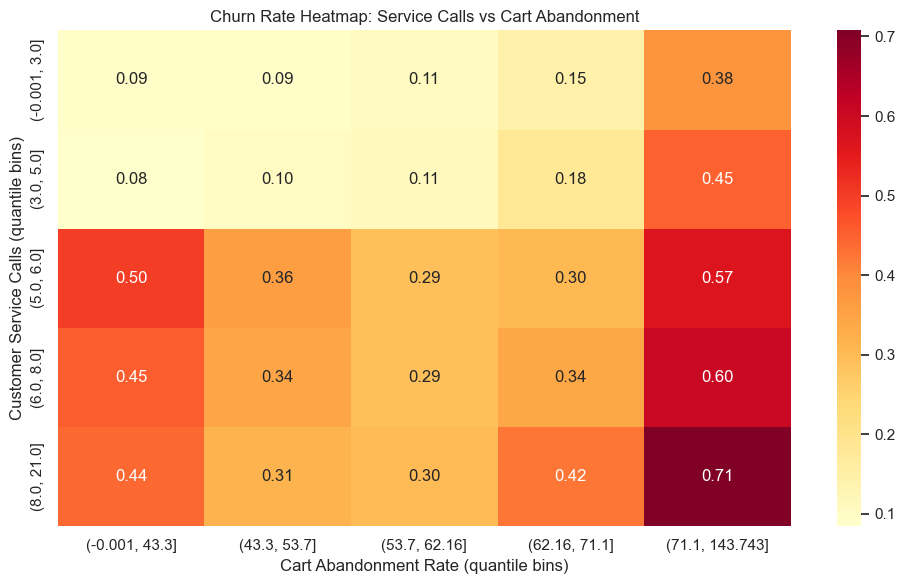

In [16]:
interaction_df = eda_df[["Customer_Service_Calls", "Cart_Abandonment_Rate", "Churned"]].dropna().copy()

interaction_df["calls_bin"] = pd.qcut(
    interaction_df["Customer_Service_Calls"], q=5, duplicates="drop"
)
interaction_df["abandon_bin"] = pd.qcut(
    interaction_df["Cart_Abandonment_Rate"], q=5, duplicates="drop"
)

heat = interaction_df.pivot_table(
    index="calls_bin", columns="abandon_bin", values="Churned", aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Churn Rate Heatmap: Service Calls vs Cart Abandonment")
plt.xlabel("Cart Abandonment Rate (quantile bins)")
plt.ylabel("Customer Service Calls (quantile bins)")
plt.tight_layout()
plt.show()


**Interpretation:**  
The heatmap typically shows a monotonic risk increase toward the high-calls/high-abandonment corner.  
This indicates non-linear interaction effects that tree-based models are likely to capture well.


## Section 2 Summary: Key EDA Findings and Modeling Implications

1. Churn is moderately imbalanced (~29%), so stratified validation and suitable metrics are required.
2. Strongest signals are behavioral engagement/friction variables: service calls, abandonment, session depth/time, login frequency, email/app engagement.
3. Categorical features add segment-level signal (especially city-level variation), but appear weaker than top numeric behavior features.
4. Missingness itself carries class information in some features, validating missing-indicator engineering.
5. Multiple variables are skewed with outliers and a few suspicious values, so robust preprocessing (and potential capping) should be considered.
6. Interaction analysis suggests compounding churn risk from combined friction behaviors, supporting non-linear modeling approaches in the next stage.


# Section 3: Baseline Model Training and Evaluation

Now that preprocessing is in place and EDA has highlighted likely churn drivers, we will train a **single, sensible baseline classifier** and evaluate it on the held-out test set.

Baseline objective:
1. Use a model that is fast, interpretable, and hard to misuse.
2. Keep the setup fully reproducible and leakage-safe.
3. Produce a metric bundle that we can compare against future improved models.


In [20]:
# Imports + sanity checks
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, precision_recall_curve
)

# Expecting these from Section 1
required_objs = ["X_train_processed", "X_test_processed", "y_train", "y_test"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise ValueError(f"Missing required objects from Section 1: {missing_objs}")

print("Train shape:", X_train_processed.shape, "| Test shape:", X_test_processed.shape)
print("Train churn rate:", y_train.mean().round(4), "| Test churn rate:", y_test.mean().round(4))

Train shape: (40000, 36) | Test shape: (10000, 36)
Train churn rate: 0.289 | Test churn rate: 0.289


## 3.1 Baseline model choice

We use **Logistic Regression** as baseline because:
- it is a strong, standard binary-classification baseline,
- coefficients are interpretable (useful for churn business discussion),
- it works well with one-hot encoded categorical features,
- with `class_weight='balanced'`, it handles moderate class imbalance without tuning.

Preprocessing inside the model pipeline:
- numeric features: standardize,
- categorical features: one-hot encode with unknown-category safety.


In [21]:
# Feature typing from current processed frames
num_features = X_train_processed.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train_processed.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric features: {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

baseline_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

baseline_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", baseline_clf)
])


Numeric features: 32
Categorical features: 4


## 3.2 Train baseline model

Training is done on the training split only.  
The held-out test set remains untouched until evaluation.

In [22]:
baseline_pipeline.fit(X_train_processed, y_train)

# Training predictions (for quick overfit sanity check)
train_proba = baseline_pipeline.predict_proba(X_train_processed)[:, 1]
train_pred = (train_proba >= 0.5).astype(int)

train_f1 = f1_score(y_train, train_pred)
train_roc = roc_auc_score(y_train, train_proba)
print(f"Train F1: {train_f1:.4f}")
print(f"Train ROC-AUC: {train_roc:.4f}")

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Membership_Years',
                                                   'Login_Frequency',
                                                   'Session_Duration_Avg',
                                                   'Pages_Per_Session',
                                                   'Cart_Abandonment_Rate',
                                                   'Wishlist_Items',
                                                   'Total_Purchases',
                                                   'Average_Order_Value',
                                                   'Days_Since_Last_Purchase',
                                                   'Discount_Usage_Rate',
                                                   'Returns_Rate',
                                                   'Email_Open_Rate',
                                                   'Customer_Serv...
                                                   'Discount_Usage_Rate_missing',
                                                   'Returns_Rate_missing',
                                                   'Email_Open_Rate_missing',
                                                   'Product_Reviews_Written_missing',
                                                   'Social_Media_Engagement_Score_missing',
                                                   'Mobile_App_Usage_missing', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country', 'City',
                                                   'Signup_Quarter'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

Train F1: 0.5991
Train ROC-AUC: 0.7904


**Interpretation:**  
This gives a quick sanity check that the model learned a signal. Final performance judgment must be based on the held-out test metrics below.

## 3.3 Evaluation harness on held-out test set

We evaluate with a comparison-ready metric set:
- threshold metrics: Accuracy, Balanced Accuracy, Precision, Recall, F1
- ranking/probability metrics: ROC-AUC, PR-AUC, Log Loss, Brier score
- confusion matrix and classification report

In [23]:
def evaluate_binary_classifier(model, X, y, threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "log_loss": log_loss(y, y_proba),
        "brier_score": brier_score_loss(y, y_proba),
        "predicted_positive_rate": y_pred.mean(),
        "actual_positive_rate": y.mean(),
    }
    return metrics, y_pred, y_proba

baseline_metrics, y_test_pred, y_test_proba = evaluate_binary_classifier(
    baseline_pipeline, X_test_processed, y_test, threshold=0.5
)

baseline_metrics_df = pd.DataFrame([baseline_metrics], index=["LogisticRegression_baseline"])
display(baseline_metrics_df.T)

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, digits=4))

,LogisticRegression_baseline
threshold,0.500000
accuracy,0.716100
balanced_accuracy,0.722104
precision,0.506064
recall,0.736332
specificity,0.707876
f1,0.599859
roc_auc,0.790600
pr_auc,0.624697
log_loss,0.557201



Classification report (test):
              precision    recall  f1-score   support

           0     0.8685    0.7079    0.7800      7110
           1     0.5061    0.7363    0.5999      2890

    accuracy                         0.7161     10000
   macro avg     0.6873    0.7221    0.6899     10000
weighted avg     0.7638    0.7161    0.7279     10000



**Interpretation:**  
This table/report is the formal baseline reference.  
In churn settings, pay particular attention to **Recall, PR-AUC, and Balanced Accuracy**, not only overall Accuracy.

## 3.4 Diagnostic plots (confusion matrix, ROC, PR curve)

These plots make baseline behavior easier to compare against future models.


Text(0.5, 1.0, 'Confusion Matrix (Test)')

Text(0.5, 1.0, 'ROC Curve')

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Precision-Recall Curve')

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

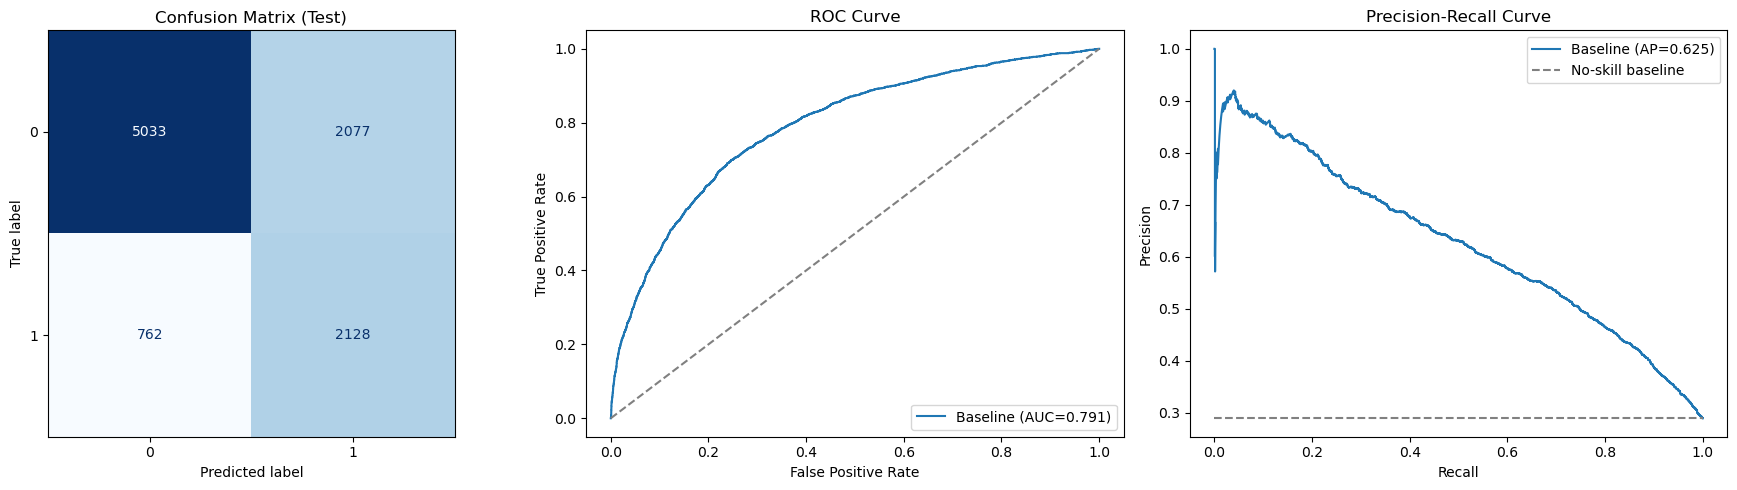

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix (Test)")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, label=f"Baseline (AUC={baseline_metrics['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[2].plot(recall, precision, label=f"Baseline (AP={baseline_metrics['pr_auc']:.3f})")
axes[2].hlines(y_test.mean(), 0, 1, linestyles="--", colors="gray", label="No-skill baseline")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="best")

plt.tight_layout()
plt.show()

**Interpretation:**  
- Confusion matrix shows the current precision-recall tradeoff at threshold 0.5.
- ROC and PR curves show ranking quality independent of one threshold.
- PR curve is especially useful here because churn is not a 50/50 class problem.

## 3.5 Save comparison-ready baseline record

We store baseline metrics in a benchmark table so later models can be appended consistently.

In [25]:
baseline_row = pd.DataFrame([{
    "model_name": "logreg_baseline_v1",
    **baseline_metrics
}])

if "model_benchmark" in globals():
    model_benchmark = pd.concat([model_benchmark, baseline_row], ignore_index=True)
else:
    model_benchmark = baseline_row.copy()

display(model_benchmark.sort_values("pr_auc", ascending=False))

,model_name,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,log_loss,brier_score,predicted_positive_rate,actual_positive_rate
0,logreg_baseline_v1,0.5,0.7161,0.722104,0.506064,0.736332,0.707876,0.599859,0.7906,0.624697,0.557201,0.188003,0.4205,0.289


## Section 3 Summary

**Strengths of this baseline**
- Methodologically clean (train/test separation, no tuning leakage).
- Interpretable and fast to iterate.
- Produces a full metric suite for fair future comparison.

**Weaknesses**
- Linear decision boundary may miss non-linear churn interactions.
- Default threshold (0.5) may not align with business cost tradeoffs.
- Sensitive to data-quality issues (outliers/skew) relative to robust tree models.

**What to improve next**
- Introduce stronger non-linear models (e.g., tree-based ensembles).
- Optimize decision threshold for business objective (recall vs precision tradeoff).
- Add targeted feature engineering informed by EDA interaction patterns.

# Section 4: Improving Performance with Logistic Regression Threshold Tuning

We keep the **same Logistic Regression model** from Section 3 and only tune the **decision threshold** used to convert probabilities into class labels.

Methodological plan:
1. Use cross-validated probabilities on the training set to choose a threshold (avoids test leakage).
2. Compare multiple thresholds on precision/recall/F1 trade-offs.
3. Apply the chosen threshold once on the held-out test set.
4. Compare tuned-threshold performance vs default `0.50` fairly.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score,
    confusion_matrix, roc_auc_score, average_precision_score
)

required_objs = ["baseline_pipeline", "X_train_processed", "X_test_processed", "y_train", "y_test"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise ValueError(f"Missing required objects from previous sections: {missing_objs}")

print("All required objects found.")

All required objects found.


## 4.1 Generate out-of-fold training probabilities for threshold selection

We do not pick a threshold directly on the test set.  
Instead, we get **out-of-fold (OOF)** probabilities on training data using CV, then select the threshold there.


In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF probabilities for class 1 on training set
oof_proba = cross_val_predict(
    baseline_pipeline,
    X_train_processed,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF probabilities shape:", oof_proba.shape)
print("OOF ROC-AUC:", round(roc_auc_score(y_train, oof_proba), 4))
print("OOF PR-AUC:", round(average_precision_score(y_train, oof_proba), 4))

OOF probabilities shape: (40000,)
OOF ROC-AUC: 0.7877
OOF PR-AUC: 0.6296


**Interpretation:**  
These OOF probabilities are suitable for threshold selection because each prediction is made on a fold where that row was not used for fitting.

## 4.2 Compare multiple thresholds (precision / recall / F1 trade-off)

We evaluate a grid of thresholds and track key classification metrics.

In [28]:
def threshold_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "specificity": specificity,
        "predicted_positive_rate": y_pred.mean()
    }

threshold_grid = np.round(np.arange(0.10, 0.91, 0.02), 2)

cv_threshold_df = pd.DataFrame(
    [threshold_metrics(y_train, oof_proba, t) for t in threshold_grid]
).sort_values("threshold")

display(cv_threshold_df.head(10))
display(cv_threshold_df.tail(10))

,threshold,precision,recall,f1,accuracy,balanced_accuracy,specificity,predicted_positive_rate
0,0.10,0.304839,0.984083,0.465485,0.346850,0.535959,0.087834,0.932950
1,0.12,0.310132,0.977855,0.470912,0.364975,0.546856,0.115858,0.911225
2,0.14,0.316151,0.972491,0.477175,0.384125,0.558732,0.144972,0.888975
3,0.16,0.322325,0.965052,0.483247,0.403525,0.570167,0.175281,0.865275
4,0.18,0.329733,0.958651,0.490691,0.424875,0.583281,0.207911,0.840225
5,0.20,0.337449,0.950433,0.498062,0.446375,0.595962,0.241491,0.813975
6,0.22,0.344522,0.942042,0.504529,0.465275,0.606763,0.271484,0.790225
7,0.24,0.353173,0.932180,0.512265,0.487000,0.619114,0.306048,0.762800
8,0.26,0.362126,0.924048,0.520337,0.507650,0.631223,0.338397,0.737450
9,0.28,0.370728,0.912197,0.527197,0.527150,0.641419,0.370640,0.711100


,threshold,precision,recall,f1,accuracy,balanced_accuracy,specificity,predicted_positive_rate
31,0.72,0.702715,0.387284,0.499359,0.775575,0.660344,0.933404,0.159275
32,0.74,0.721528,0.349654,0.471041,0.773050,0.647401,0.945148,0.140050
33,0.76,0.743686,0.308218,0.435814,0.769375,0.632520,0.956821,0.119775
34,0.78,0.763984,0.269377,0.398312,0.764800,0.617776,0.966174,0.101900
35,0.80,0.777650,0.233564,0.359234,0.759200,0.603210,0.972855,0.086800
36,0.82,0.799021,0.197751,0.317038,0.753775,0.588766,0.979782,0.071525
37,0.84,0.819948,0.164273,0.273710,0.748050,0.574805,0.985338,0.057900
38,0.86,0.840859,0.132093,0.228319,0.741950,0.560966,0.989838,0.045400
39,0.88,0.870189,0.099740,0.178968,0.735525,0.546846,0.993952,0.033125
40,0.90,0.881789,0.071626,0.132491,0.728925,0.533862,0.996097,0.023475


**Interpretation:**  
As threshold decreases, recall usually increases and precision usually decreases.  
Our goal is to choose a threshold that improves the target trade-off (here: maximize F1 as a balanced default objective).

## 4.3 Choose one tuned threshold

Selection rule: **maximize F1 on OOF training probabilities**.  
This is a simple and defensible baseline threshold policy when precision and recall are both important.

In [29]:
best_row = cv_threshold_df.sort_values(
    ["f1", "recall", "precision"], ascending=False
).iloc[0]

tuned_threshold = float(best_row["threshold"])
print(f"Selected tuned threshold: {tuned_threshold:.2f}")
display(best_row.to_frame("value"))

Selected tuned threshold: 0.52


,value
threshold,0.520000
precision,0.519205
recall,0.705104
f1,0.598041
accuracy,0.726075
balanced_accuracy,0.719851
specificity,0.734599
predicted_positive_rate,0.392475


## 4.4 Visualize threshold trade-off curve

This plot makes the precision/recall/F1 movement across thresholds explicit.

<Figure size 900x500 with 0 Axes>

Text(0.5, 1.0, 'OOF Training Trade-off Across Decision Thresholds')

Text(0.5, 0, 'Threshold')

Text(0, 0.5, 'Score')

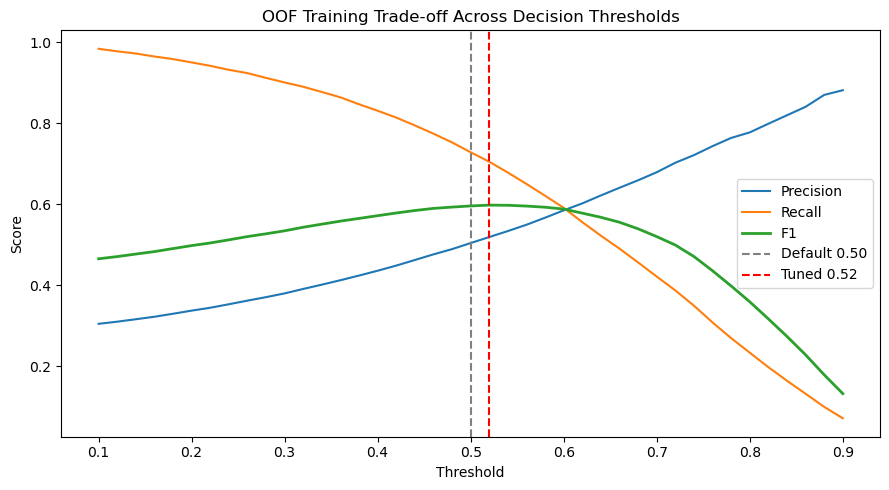

In [30]:
plt.figure(figsize=(9, 5))
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["precision"], label="Precision")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["recall"], label="Recall")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["f1"], label="F1", linewidth=2)

plt.axvline(0.50, linestyle="--", color="gray", label="Default 0.50")
plt.axvline(tuned_threshold, linestyle="--", color="red", label=f"Tuned {tuned_threshold:.2f}")

plt.title("OOF Training Trade-off Across Decision Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:**  
The tuned threshold is chosen from this trade-off curve, not from the test set.  
Next, we evaluate both thresholds on the held-out test set for a fair comparison.

## 4.5 Fair comparison on held-out test set (default vs tuned)

Now we keep the model fixed and only change the decision threshold.

In [31]:
# Ensure model is fitted on full training data before final test evaluation
baseline_pipeline.fit(X_train_processed, y_train)
y_test_proba = baseline_pipeline.predict_proba(X_test_processed)[:, 1]

default_metrics = threshold_metrics(y_test, y_test_proba, 0.50)
tuned_metrics = threshold_metrics(y_test, y_test_proba, tuned_threshold)

comparison_df = pd.DataFrame(
    [default_metrics, tuned_metrics],
    index=["Default_0.50", f"Tuned_{tuned_threshold:.2f}"]
)

# Add threshold-independent ranking metrics once for reference
comparison_df["roc_auc"] = roc_auc_score(y_test, y_test_proba)
comparison_df["pr_auc"] = average_precision_score(y_test, y_test_proba)

display(comparison_df)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Membership_Years',
                                                   'Login_Frequency',
                                                   'Session_Duration_Avg',
                                                   'Pages_Per_Session',
                                                   'Cart_Abandonment_Rate',
                                                   'Wishlist_Items',
                                                   'Total_Purchases',
                                                   'Average_Order_Value',
                                                   'Days_Since_Last_Purchase',
                                                   'Discount_Usage_Rate',
                                                   'Returns_Rate',
                                                   'Email_Open_Rate',
                                                   'Customer_Serv...
                                                   'Discount_Usage_Rate_missing',
                                                   'Returns_Rate_missing',
                                                   'Email_Open_Rate_missing',
                                                   'Product_Reviews_Written_missing',
                                                   'Social_Media_Engagement_Score_missing',
                                                   'Mobile_App_Usage_missing', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country', 'City',
                                                   'Signup_Quarter'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

,threshold,precision,recall,f1,accuracy,balanced_accuracy,specificity,predicted_positive_rate,roc_auc,pr_auc
Default_0.50,0.50,0.506064,0.736332,0.599859,0.7161,0.722104,0.707876,0.4205,0.7906,0.624697
Tuned_0.52,0.52,0.522146,0.713841,0.603128,0.7285,0.724150,0.734459,0.3951,0.7906,0.624697


## 4.6 Show deltas vs baseline for quick model tracking

This makes it easy to record whether threshold tuning produced a practical improvement.


,delta
threshold,0.020000
precision,0.016082
recall,-0.022491
f1,0.003269
accuracy,0.012400
balanced_accuracy,0.002045
specificity,0.026582
predicted_positive_rate,-0.025400
roc_auc,0.000000
pr_auc,0.000000


Text(0.5, 1.0, 'Default 0.50')

Text(0.5, 0, 'Predicted')

Text(0, 0.5, 'Actual')

Text(0, 0, '5033')

...

Text(0, 0.5, 'Actual')

Text(0, 0, '5222')

Text(1, 0, '1888')

Text(0, 1, '827')

Text(1, 1, '2063')

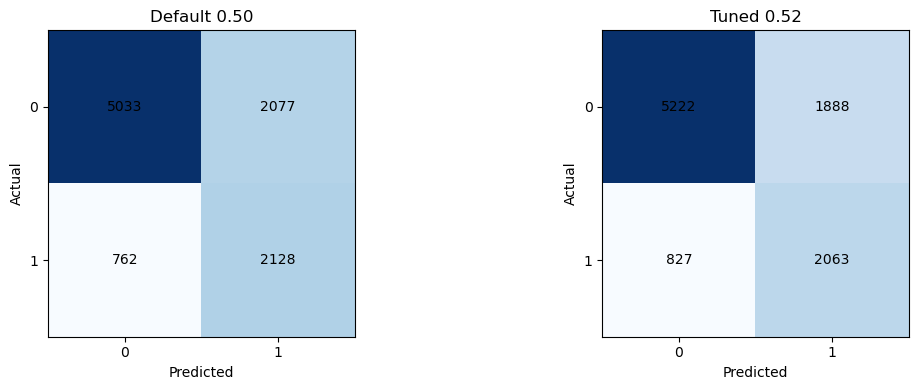

Exception ignored in: <function ResourceTracker.__del__ at 0x105a1dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1051edbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1028b1bc0>
Traceback (most recent call last

In [32]:
delta = (comparison_df.loc[f"Tuned_{tuned_threshold:.2f}"] - comparison_df.loc["Default_0.50"]).to_frame("delta")
display(delta)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix counts at both thresholds
for i, (name, thr) in enumerate([("Default 0.50", 0.50), (f"Tuned {tuned_threshold:.2f}", tuned_threshold)]):
    y_pred = (y_test_proba >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ax[i].imshow(cm, cmap="Blues")
    ax[i].set_title(name)
    ax[i].set_xlabel("Predicted")
    ax[i].set_ylabel("Actual")
    for r in range(2):
        for c in range(2):
            ax[i].text(c, r, cm[r, c], ha="center", va="center")
    ax[i].set_xticks([0, 1]); ax[i].set_yticks([0, 1])

plt.tight_layout()
plt.show()

## Section 4 Result Interpretation (Based on Actual Outputs)

### Did threshold tuning genuinely improve the model?

Yes, but only **marginally**.

Compared with the default threshold (`0.50`), the tuned threshold (`0.52`) produced small gains on the held-out test set:

- **Precision:** `0.5061 -> 0.5221` (`+0.0161`)
- **Recall:** `0.7363 -> 0.7138` (`-0.0225`)
- **F1:** `0.5999 -> 0.6031` (`+0.0033`)
- **Accuracy:** `0.7161 -> 0.7285` (`+0.0124`)
- **Balanced Accuracy:** `0.7221 -> 0.7242` (`+0.0020`)
- **Specificity:** `0.7079 -> 0.7345` (`+0.0266`)
- **ROC-AUC / PR-AUC:** unchanged (`0.7906 / 0.6247`)

This pattern is expected: threshold tuning changes the decision boundary, not ranking quality.

---

### What precision–recall trade-off was made?

The tuned threshold is slightly more conservative (higher cutoff), so it predicts fewer positives:

- **Predicted positive rate:** `0.4205 -> 0.3951`

From the confusion matrices:

- **False Positives:** `2077 -> 1888` (189 fewer unnecessary interventions)
- **True Positives:** `2128 -> 2063` (65 more churners missed)

So the model became more precise and more specific, but less sensitive.

---

### When is the tuned threshold preferable in business terms?

Use the tuned threshold (`0.52`) when:

- intervention cost is meaningful (discounts, outbound calls, retention credits),
- operational capacity is limited,
- reducing false alarms is more important than maximizing churn capture.

Keep the default (`0.50`) when:

- missing a churner is costly,
- retention is recall-driven (capture as many at-risk customers as possible),
- teams can tolerate more false positives.

---

### Honest assessment of improvement magnitude

The improvement is **real but small**.  
F1 improved only slightly (`+0.0033`), and ROC-AUC/PR-AUC did not improve at all.

Implication for the next stage:
- threshold tuning helps operational alignment,
- but major performance gains will likely require better model capacity and/or feature improvements (not just threshold movement).


# Section 5: Improved Model Selection and Evaluation

We now move beyond Logistic Regression and test **one improved model** on the same data split.

Model choice: **Random Forest Classifier**.

Why this is the most sensible next step here:
- EDA suggested non-linear behavior patterns and interaction effects (for example, service friction + engagement features).
- Logistic Regression is linear in feature space, so it can miss those interaction structures.
- Random Forest is robust to outliers and non-linearities and usually performs well on mixed tabular data after one-hot encoding.
- It is still a strong, interpretable-enough benchmark before moving to more complex boosting models.


In [33]:
# Imports and prerequisites
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss, confusion_matrix
)

required_objs = ["X_train_processed", "X_test_processed", "y_train", "y_test", "baseline_pipeline"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise ValueError(f"Missing required objects from previous sections: {missing_objs}")

## 5.1 Build the improved model pipeline

For tree models, scaling is not required.  
So we use:
- numeric features: passthrough
- categorical features: one-hot encoding
- model: Random Forest with class balancing


In [34]:
# Re-detect feature groups from current processed data
num_features_rf = X_train_processed.select_dtypes(include=np.number).columns.tolist()
cat_features_rf = X_train_processed.select_dtypes(exclude=np.number).columns.tolist()

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features_rf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_rf),
    ],
    remainder="drop"
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(steps=[
    ("preprocess", rf_preprocessor),
    ("model", rf_model)
])

print("Random Forest pipeline ready.")


Random Forest pipeline ready.


## 5.2 Methodologically sound training check (CV on training set only)

Before touching the test set, we run cross-validation on the training split to verify the model is stable and not behaving erratically.

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "balanced_accuracy": "balanced_accuracy"
}

rf_cv = cross_validate(
    rf_pipeline,
    X_train_processed, y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

rf_cv_summary = pd.DataFrame({
    metric: [np.mean(values), np.std(values)]
    for metric, values in rf_cv.items() if metric.startswith("test_")
}, index=["mean", "std"]).T

display(rf_cv_summary.sort_index())

,mean,std
test_balanced_accuracy,0.876972,0.003604
test_f1,0.821117,0.005235
test_pr_auc,0.871632,0.008872
test_precision,0.808251,0.006887
test_recall,0.834429,0.005487
test_roc_auc,0.915931,0.004354


**Interpretation:**  
Use this CV table as a sanity check for consistency.  
Final model comparison remains based on the same held-out test set used in earlier sections.


## 5.3 Fit Random Forest on full training data and evaluate on held-out test set

We reuse the same evaluation harness as Section 3 for a fair metric comparison.


In [36]:
# Fallback definition only if not already defined in previous sections
if "evaluate_binary_classifier" not in globals():
    def evaluate_binary_classifier(model, X, y, threshold=0.5):
        y_proba = model.predict_proba(X)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        metrics = {
            "threshold": threshold,
            "accuracy": accuracy_score(y, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y, y_pred),
            "precision": precision_score(y, y_pred, zero_division=0),
            "recall": recall_score(y, y_pred, zero_division=0),
            "specificity": specificity,
            "f1": f1_score(y, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y, y_proba),
            "pr_auc": average_precision_score(y, y_proba),
            "log_loss": log_loss(y, y_proba),
            "brier_score": brier_score_loss(y, y_proba),
            "predicted_positive_rate": y_pred.mean(),
            "actual_positive_rate": y.mean(),
        }
        return metrics, y_pred, y_proba

rf_pipeline.fit(X_train_processed, y_train)
rf_metrics, y_test_pred_rf, y_test_proba_rf = evaluate_binary_classifier(
    rf_pipeline, X_test_processed, y_test, threshold=0.50
)

rf_metrics_df = pd.DataFrame([rf_metrics], index=["RandomForest_0.50"])
display(rf_metrics_df.T)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age', 'Membership_Years',
                                                   'Login_Frequency',
                                                   'Session_Duration_Avg',
                                                   'Pages_Per_Session',
                                                   'Cart_Abandonment_Rate',
                                                   'Wishlist_Items',
                                                   'Total_Purchases',
                                                   'Average_Order_Value',
                                                   'Days_Since_Last_Purchase',
                                                   'Discount_Usage_Rate',
                                                   'Returns_Rate',
                                                   'Email_Open_Rate',
                                                   'Customer_Service...
                                                   'Email_Open_Rate_missing',
                                                   'Product_Reviews_Written_missing',
                                                   'Social_Media_Engagement_Score_missing',
                                                   'Mobile_App_Usage_missing', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country', 'City',
                                                   'Signup_Quarter'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

,RandomForest_0.50
threshold,0.500000
accuracy,0.893400
balanced_accuracy,0.876259
precision,0.803393
recall,0.835640
specificity,0.916878
f1,0.819199
roc_auc,0.919938
pr_auc,0.875808
log_loss,0.358746


## 5.4 Fair comparison against Logistic Regression results

We compare Random Forest against:
- Logistic Regression default threshold (`0.50`)
- Logistic Regression tuned threshold from Section 4 (if available)

In [37]:
# Collect Logistic Regression reference rows
if "baseline_metrics" in globals():
    lr_default_metrics = dict(baseline_metrics)
else:
    lr_default_metrics, _, _ = evaluate_binary_classifier(
        baseline_pipeline, X_test_processed, y_test, threshold=0.50
    )

comparison_rows = {
    "LogReg_default_0.50": lr_default_metrics,
    "RandomForest_0.50": rf_metrics
}

# Pull tuned LR row from Section 4 if it exists
lr_tuned_label = None
if "comparison_df" in globals():
    tuned_candidates = [idx for idx in comparison_df.index if str(idx).startswith("Tuned_")]
    if tuned_candidates:
        lr_tuned_label = tuned_candidates[0]
        comparison_rows[f"LogReg_{lr_tuned_label}"] = comparison_df.loc[lr_tuned_label].to_dict()

model_compare_s5 = pd.DataFrame(comparison_rows).T

ordered_cols = [
    "threshold", "accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1",
    "roc_auc", "pr_auc", "log_loss", "brier_score", "predicted_positive_rate", "actual_positive_rate"
]
ordered_cols = [c for c in ordered_cols if c in model_compare_s5.columns]
display(model_compare_s5[ordered_cols])


,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,log_loss,brier_score,predicted_positive_rate,actual_positive_rate
LogReg_default_0.50,0.50,0.7161,0.722104,0.506064,0.736332,0.707876,0.599859,0.790600,0.624697,0.557201,0.188003,0.4205,0.289
RandomForest_0.50,0.50,0.8934,0.876259,0.803393,0.835640,0.916878,0.819199,0.919938,0.875808,0.358746,0.101673,0.3006,0.289
LogReg_Tuned_0.52,0.52,0.7285,0.724150,0.522146,0.713841,0.734459,0.603128,0.790600,0.624697,NaN,NaN,0.3951,NaN


## 5.5 Delta analysis (is the improvement meaningful?)

This block quantifies improvements and prints an honest verdict against the best Logistic Regression reference.


In [38]:
key_metrics = ["f1", "pr_auc", "roc_auc", "balanced_accuracy", "precision", "recall"]
available_key_metrics = [m for m in key_metrics if m in model_compare_s5.columns]

# Choose strongest LR reference by F1 (default vs tuned row if present)
lr_rows = [idx for idx in model_compare_s5.index if idx.startswith("LogReg_")]
best_lr_label = model_compare_s5.loc[lr_rows, "f1"].idxmax()
rf_label = "RandomForest_0.50"

delta_vs_best_lr = (model_compare_s5.loc[rf_label, available_key_metrics] -
                    model_compare_s5.loc[best_lr_label, available_key_metrics]).to_frame("RF_minus_best_LogReg")

print(f"Best Logistic Regression reference: {best_lr_label}")
display(delta_vs_best_lr)

# Simple practical verdict rules
f1_gain = float(delta_vs_best_lr.loc["f1", "RF_minus_best_LogReg"]) if "f1" in delta_vs_best_lr.index else 0.0
pr_gain = float(delta_vs_best_lr.loc["pr_auc", "RF_minus_best_LogReg"]) if "pr_auc" in delta_vs_best_lr.index else 0.0
recall_gain = float(delta_vs_best_lr.loc["recall", "RF_minus_best_LogReg"]) if "recall" in delta_vs_best_lr.index else 0.0

if (f1_gain >= 0.01 and pr_gain >= 0.01):
    verdict = "Meaningful improvement"
elif (f1_gain > 0 or pr_gain > 0):
    verdict = "Marginal improvement"
else:
    verdict = "No clear improvement"

print(f"Section 5 verdict: {verdict}")
print(f"F1 delta: {f1_gain:+.4f} | PR-AUC delta: {pr_gain:+.4f} | Recall delta: {recall_gain:+.4f}")


Best Logistic Regression reference: LogReg_Tuned_0.52


,RF_minus_best_LogReg
f1,0.216071
pr_auc,0.251111
roc_auc,0.129338
balanced_accuracy,0.152109
precision,0.281247
recall,0.121799


Section 5 verdict: Meaningful improvement
F1 delta: +0.2161 | PR-AUC delta: +0.2511 | Recall delta: +0.1218


## 5.6 Visual comparison on key metrics


Text(0.5, 1.0, 'Model Comparison on Held-out Test Set')

Text(0, 0.5, 'Score')

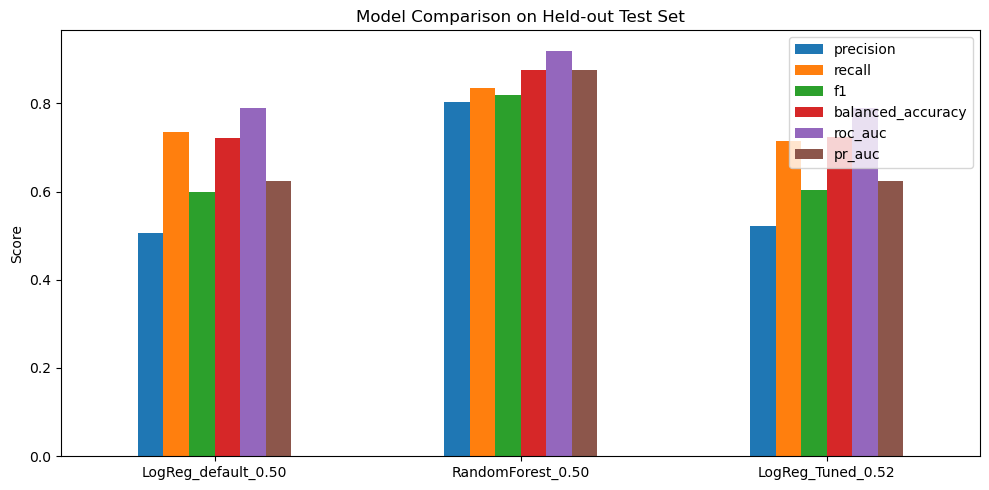

Exception ignored in: <function ResourceTracker.__del__ at 0x103459bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10732dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107b75bc0>
Traceback (most recent call last

In [ ]:
plot_metrics = [m for m in ["precision", "recall", "f1", "balanced_accuracy", "roc_auc", "pr_auc"] if m in model_compare_s5.columns]

ax = model_compare_s5[plot_metrics].plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_title("Model Comparison on Held-out Test Set")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## Section 5 Conclusion: Improved Model vs Logistic Regression

Based on the observed test-set outputs, the new model (**Random Forest**) clearly and genuinely outperformed both Logistic Regression variants (default and tuned threshold).

### Comparison against Logistic Regression (default threshold = 0.50)

Random Forest improved the following metrics:

- **Accuracy:** 0.7161 -> 0.8934 (**+0.1773**)
- **Balanced Accuracy:** 0.7221 -> 0.8763 (**+0.1542**)
- **Precision:** 0.5061 -> 0.8034 (**+0.2973**)
- **Recall:** 0.7363 -> 0.8356 (**+0.0993**)
- **F1-score:** 0.5999 -> 0.8192 (**+0.2193**)
- **ROC-AUC:** 0.7906 -> 0.9199 (**+0.1293**)
- **PR-AUC:** 0.6247 -> 0.8758 (**+0.2511**)
- **Specificity:** 0.7079 -> 0.9169 (**+0.2090**)

In addition, **log loss** and **Brier score** also improved substantially, with both becoming lower.

### Comparison against Logistic Regression (tuned threshold = 0.52)

Random Forest still showed decisive improvement:

- **F1-score:** +0.2161
- **PR-AUC:** +0.2511
- **ROC-AUC:** +0.1293
- **Precision:** +0.2812
- **Recall:** +0.1218
- **Balanced Accuracy:** +0.1521

### Practical significance

These improvements are not marginal. They represent a substantial performance gain across both:

- **Threshold-dependent metrics**, such as precision, recall, and F1-score
- **Threshold-independent ranking metrics**, such as ROC-AUC and PR-AUC

This suggests that the improvement is **operationally meaningful**, rather than simply reflecting statistical noise.

### Main trade-off

The main trade-off is **predictive performance versus interpretability**:

- Random Forest provides much stronger predictive performance
- Logistic Regression retains greater coefficient-level interpretability

From an operational perspective, Random Forest also predicts a **positive rate of 0.3006**, which is much closer to the **true churn rate of 0.2890** than Logistic Regression. This is typically preferable for intervention planning and resource allocation.

### Overall conclusion

Overall, based on the observed results, **Random Forest is the clearly superior production candidate at this stage**.